In [47]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import jensenshannon
from torch.nn.utils.rnn import pack_padded_sequence
import torch
import torch.nn as nn
import random
from sklearn.model_selection import KFold


# prepare the labels y

In [10]:
dataset = pd.read_parquet('/Users/weberlin/src/cs229/cs229_rna_folding/kinpfn_testing_set/parquet_parsing/test_val_dataset.parquet')
# comment out this line on your computer, add own path

In [11]:
arr_fpts = np.array([row for row in dataset['fpts']])

In [12]:
arr_fpts.shape

(2654, 1000)

In [13]:
np.min(arr_fpts)

0.0

In [14]:
np.max(arr_fpts)

297458098.413

In [15]:
np.where(arr_fpts == 0)

(array([ 251,  258,  274,  274,  274,  274,  274,  274,  274,  333,  349,
         349,  453,  459,  464,  465,  465,  465,  465,  478,  480,  480,
         482,  484,  484,  484,  484,  491,  491,  491,  491,  527, 1373,
        1441, 1490, 1490, 1490, 1497, 1510, 1510, 1510, 1514, 1514, 1531,
        1897, 2157, 2167, 2167, 2179, 2183, 2201, 2220, 2235, 2245, 2248,
        2253, 2253, 2255, 2256, 2256, 2257, 2267, 2282, 2282, 2282, 2295,
        2296, 2296, 2298, 2298, 2316, 2316, 2322, 2328, 2328, 2328, 2355,
        2355, 2361, 2361, 2361, 2381, 2381, 2390, 2446]),
 array([ 81, 180, 186, 211, 222, 408, 472, 555, 965, 153, 412, 864, 560,
         11, 389,  66, 250, 625, 641, 903, 420, 612, 230, 276, 306, 452,
        783,  40, 141, 432, 792, 643, 805, 460, 148, 175, 728, 730, 208,
        270, 368, 777, 928, 529, 320, 454, 468, 774, 626,  53, 920, 921,
        808, 525, 892, 135, 360, 589, 617, 702, 865, 711,  70, 601, 719,
        792, 226, 597, 553, 751,   8, 332, 531, 396, 552, 6

In [16]:
where_arr_fpts_nonzero = np.where(arr_fpts != 0)
arr_logfpts = np.log(arr_fpts[where_arr_fpts_nonzero])

In [17]:
np.min(arr_logfpts)

-6.907755278982137

In [18]:
np.max(arr_logfpts)

19.510783927359686

In [19]:
arr_logfpts.shape

(2653915,)

In [20]:
n_bins = 50

binedges_logfpt = np.linspace(np.min(arr_logfpts), np.max(arr_logfpts), n_bins+1)

In [21]:
arr_hist_logfpts = np.zeros((dataset.shape[0], n_bins))
for index, row in dataset.iterrows():
    fpts = row['fpts']
    where_fpts_nonzero = np.where(fpts != 0)
    logfpts = np.log(fpts[where_fpts_nonzero])
    hist_logfpts, _ = np.histogram(logfpts, binedges_logfpt, density=True)
    hist_logfpts /= np.sum(hist_logfpts) # normalize so that values add to 1; this does not reflect the probability density
    arr_hist_logfpts[index] = hist_logfpts


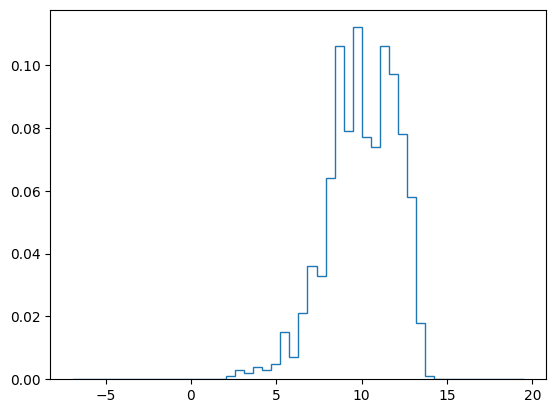

In [22]:
plt.stairs(arr_hist_logfpts[67], binedges_logfpt)

In [23]:
y = arr_hist_logfpts

In [24]:
np.sum(y, axis=1)

array([1., 1., 1., ..., 1., 1., 1.])

In [25]:
print(y.shape)

(2654, 50)


# prepare the features X

In [26]:
print(dataset.columns)

Index(['filepath', 'sequence', 'length', 'mfe_from_file',
       'dot_bracket_from_file', 'fpts', 'gc_content', 'freq_A', 'freq_U',
       'freq_G',
       ...
       'min_11_tree_dist', 'min_12_tree_dist', 'min_13_tree_dist',
       'min_14_tree_dist', 'min_15_tree_dist', 'min_16_tree_dist',
       'min_17_tree_dist', 'min_18_tree_dist', 'min_19_tree_dist',
       'min_20_tree_dist'],
      dtype='str', length=110)


In [27]:
X = dataset.drop(columns=['filepath', 'dot_bracket_from_file', 'fpts'])
for i in range(1, 21):
    X = X.drop(columns=['min_'+str(i)+'_structure'])
    X = X.drop(columns=['min_'+str(i)+'_energy'])
    X = X.drop(columns=['min_'+str(i)+'_bp_dist'])
    X = X.drop(columns=['min_'+str(i)+'_tree_dist'])
for i in ['A' , 'C' , 'G' , 'U']:
    for j in ['A', 'C', 'G', 'U', '']:
        X = X.drop(columns=['freq_'+ i + j])

In [28]:
X.shape

(2654, 7)

In [29]:
with pd.option_context('display.max_rows', None):
    print(X.iloc[0:3])

                                            sequence  length  mfe_from_file  \
0  UCAUACAGACUUAGAUAAGAAGCCGGCACUUUUAGUCCGUCUGAAU...     100         -29.30   
1  CGCUACGGUUAUCAGACUUGAUUGUAGAGGAACAUUAAGCGGAGGA...     100         -39.60   
2  GUCUGUUUAUGGAAGGUUAUUCCGUCCCGAUAGGAUUACAACAAAU...     100         -24.14   

   gc_content        mfe                                      mfe_structure  \
0        0.53 -29.299999  ((((.(((((...(((.(((((......))))).))).))))).))...   
1        0.54 -39.599998  (.(((((((((.......))))))))).).........(((..(((...   
2        0.43 -24.299999  ..(((((.((((((.....)))))).....(((((((......)))...   

   n_local_minima  
0              26  
1               8  
2              39  


In [30]:
# X = np.array(X)

In [31]:
X.shape

(2654, 7)

In [32]:
y.shape

(2654, 50)

# train the model

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42)


In [34]:
scaler = StandardScaler()

handpicked_cols = ['gc_content', 'mfe', 'n_local_minima']

#pull out the numerical features for normalization 
X_train_static = scaler.fit_transform(X_train[handpicked_cols])
X_val_static   = scaler.transform(X_val[handpicked_cols])
X_test_static  = scaler.transform(X_test[handpicked_cols])

#bucket into same-length batches so no need to pad
def bucket_and_extract(sequences, scaled_static_array, y):
    # Get the indices that would sort by length
    sort_indices = np.argsort(sequences['length'].values)
    
    # Use iloc to index the DataFrame rows directly
    sorted_df = sequences.iloc[sort_indices]
    
    # Pull out the two columns you need as plain lists
    sorted_seq       = sorted_df['sequence'].tolist()
    sorted_structure = sorted_df['mfe_structure'].tolist()
    
    sorted_static  = scaled_static_array[sort_indices]
    sorted_targets = y[sort_indices] if isinstance(y, np.ndarray) else y.iloc[sort_indices].values
    
    return sorted_seq, sorted_structure, sorted_static, sorted_targets

# Apply bucketing to each split separately
train_seq, train_structure, train_static, train_y = bucket_and_extract(X_train, X_train_static, y_train)
val_seq,   val_structure,   val_static,   val_y   = bucket_and_extract(X_val, X_val_static, y_val)
test_seq,  test_structure,  test_static,  test_y  = bucket_and_extract(X_test, X_test_static, y_test)



In [46]:
import numpy as np
from scipy.spatial.distance import jensenshannon

# --- Build the mean predictor from training data ---
# Group training targets by sequence length
length_to_mean = {}

for seq, target in zip(train_seq, train_y):
    length = len(seq)
    if length not in length_to_mean:
        length_to_mean[length] = []
    length_to_mean[length].append(target)
# Compute the mean histogram for each length
for length in length_to_mean:
    length_to_mean[length] = np.mean(length_to_mean[length], axis=0)

# --- Evaluate on validation set ---
all_preds = []
all_targets = []

for seq, target in zip(val_seq, val_y):
    length = len(seq)
    if length in length_to_mean:
        pred = length_to_mean[length]
    all_preds.append(pred)
    all_targets.append(target)

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

js_scores = [jensenshannon(all_targets[i], all_preds[i]) for i in range(len(all_targets))]
print(f"Baseline Mean JS divergence:   {np.mean(js_scores):.4f}")
print(f"Baseline Median JS divergence: {np.median(js_scores):.4f}")

Baseline Mean JS divergence:   0.3406
Baseline Median JS divergence: 0.3277


In [48]:
X_nontest, X_test, y_nontest, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

In [51]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for fold, (train_idx, val_idx) in enumerate(kf.split(X_nontest)):
    print(f"Fold {fold+1}/5")
    print(len(train_idx))
    print(len(val_idx))

Fold 1/5
1804
451
Fold 2/5
1804
451
Fold 3/5
1804
451
Fold 4/5
1804
451
Fold 5/5
1804
451


In [54]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_train_losses = []
fold_val_losses = []

# Assume X_nontest is a DataFrame and y_nontest is a numpy array
X_nontest_arr = X_nontest  # DataFrame, indexed by row
y_nontest_arr = y_nontest  # numpy array

for fold, (train_idx, val_idx) in enumerate(kf.split(X_nontest_arr)):
    print(f"Fold {fold+1}/5")

    # Split
    X_train_fold = X_nontest_arr.iloc[train_idx]
    X_val_fold   = X_nontest_arr.iloc[val_idx]
    y_train_fold = y_nontest_arr[train_idx]
    y_val_fold   = y_nontest_arr[val_idx]

    # Build mean predictor from training fold
    length_to_mean = {}
    for seq, target in zip(X_train_fold['sequence'].tolist(), y_train_fold):
        length = len(seq)
        if length not in length_to_mean:
            length_to_mean[length] = []
        length_to_mean[length].append(target)

    for length in length_to_mean:
        length_to_mean[length] = np.mean(length_to_mean[length], axis=0)

    global_mean = np.mean(list(length_to_mean.values()), axis=0)

    # Evaluate on training fold
    train_preds   = []
    train_targets = []
    for seq, target in zip(X_train_fold['sequence'].tolist(), y_train_fold):
        length = len(seq)
        pred = length_to_mean.get(length, global_mean)
        train_preds.append(pred)
        train_targets.append(target)
    train_js = [jensenshannon(train_targets[i], train_preds[i])
                for i in range(len(train_targets))]
    fold_train_losses.append(np.mean(train_js))

    # Evaluate on validation fold
    val_preds   = []
    val_targets = []
    for seq, target in zip(X_val_fold['sequence'].tolist(), y_val_fold):
        length = len(seq)
        pred = length_to_mean.get(length, global_mean)
        val_preds.append(pred)
        val_targets.append(target)
    val_js = [jensenshannon(val_targets[i], val_preds[i])
              for i in range(len(val_targets))]
    fold_val_losses.append(np.mean(val_js))

    print(f"  Train mean JS: {fold_train_losses[-1]:.4f} | Val mean JS: {fold_val_losses[-1]:.4f}")

print(f"\nMean train JS: {np.mean(fold_train_losses):.4f} ± {np.std(fold_train_losses):.4f}")
print(f"Mean val JS:   {np.mean(fold_val_losses):.4f} ± {np.std(fold_val_losses):.4f}")

Fold 1/5
  Train mean JS: 0.3253 | Val mean JS: 0.3434
Fold 2/5
  Train mean JS: 0.3240 | Val mean JS: 0.3526
Fold 3/5
  Train mean JS: 0.3240 | Val mean JS: 0.3494
Fold 4/5
  Train mean JS: 0.3239 | Val mean JS: 0.3485
Fold 5/5
  Train mean JS: 0.3276 | Val mean JS: 0.3407

Mean train JS: 0.3250 ± 0.0014
Mean val JS:   0.3469 ± 0.0043
